<a href="https://colab.research.google.com/github/RONINNNN/Customer-Churn-Prediction-using-Machine-Learning/blob/main/Predicting_Customer_Churn_in_the_Telecom_Industry_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Customer Churn in the Telecom Industry: A Business Intelligence and Data Mining Approach

**Module:** Business Intelligence and Data Mining  
**Assessment:** Group Project Portfolio  
**Project theme:** Customer churn prediction for a telecom business  
**Dataset:** Telco Customer Churn dataset

This notebook presents a complete business intelligence and data mining project on customer churn in the telecom sector. It combines report writing and practical analysis in one `.ipynb` file, as required. The notebook defines the business problem, justifies the dataset, explores and cleans the data, builds predictive models, evaluates their performance, and turns the results into business recommendations. It also reflects on ethical, privacy, and security issues linked to using customer data for predictive decision-making.

The main aim is to help a telecom company identify customers at risk of leaving and support earlier, better-targeted retention decisions.


## [1] Background of the Customer Churn Problem

Customer churn means customers ending their relationship with a business. In telecommunications, churn is a major issue because services are subscription-based and switching to a competitor is often easy. Even moderate churn can damage revenue because winning a new customer usually costs more than retaining an existing one (Han, Kamber and Pei, 2012).

From a business intelligence perspective, churn is a strong analytical problem because telecom firms already store useful operational data such as contract type, tenure, billing level, service subscriptions, and payment method. When analysed properly, this data can reveal early warning signs of churn and support proactive retention action (Few, 2013).

This project investigates churn prediction using the Telco Customer Churn dataset. The business objective is not only to predict whether a customer is likely to leave, but also to identify the factors most strongly associated with churn and translate them into practical recommendations. The project therefore links predictive modelling with decision support, which is a central aim of business intelligence (Han, Kamber and Pei, 2012).

In [24]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## [2] Dataset Description

### Source of Dataset

The project uses the **Telco Customer Churn** dataset, a widely used public dataset for retention analysis. It contains customer-level records describing demographics, subscribed services, billing information, and churn status.

### Why the dataset is suitable

This dataset is suitable because the target variable directly matches the chosen problem and the feature set reflects realistic telecom business drivers. It includes both numerical and categorical variables, which allows a full workflow of cleaning, encoding, exploratory analysis, and classification modelling. It is also large enough to support meaningful testing while still being manageable in a notebook environment (James *et al*., 2021).

### Key variables

Important variables include:

- **Tenure** – how long the customer has stayed with the company  
- **Contract** – month-to-month, one-year, or two-year agreement  
- **MonthlyCharges** – recurring bill amount  
- **TotalCharges** – cumulative amount paid  
- **InternetService / PhoneService** – subscribed services  
- **PaymentMethod** – billing behaviour indicator  
- **Churn** – target variable showing whether the customer left

These variables support both prediction and business interpretation.

In [25]:
# Load dataset safely from the notebook folder or /mnt/data
possible_files = [
    "telco.csv",
    os.path.join("/mnt/data", "telco.csv"),
]

file_path = None
for f in possible_files:
    if os.path.exists(f):
        file_path = f
        break

if file_path is None:
    raise FileNotFoundError(
        "CSV file not found. Keep the dataset in the same folder as the notebook or in /mnt/data."
    )

df = pd.read_csv(file_path)
print("Loaded file:", file_path)
df.head()

Loaded file: telco.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## [3] Data Cleaning and Feature Engineering

### [3.1] Initial Data Inspection

Before modelling, the dataset is checked for structure, data types, and missing values. This is necessary because machine learning performance depends on data quality (James *et al*., 2021).

A key issue in this dataset is the `TotalCharges` field. Some rows contain blank values, so the column may be read as text instead of numeric. Since this variable is financially important, it must be converted before analysis.

### [3.2] Cleaning strategy

The notebook converts `TotalCharges` to numeric, removes rows with missing values created by blank entries, and reviews categorical fields for consistency. The target variable `Churn` is encoded into binary form so it can be used by classification algorithms.

These steps improve reliability and make the dataset suitable for exploratory analysis and modelling (Han, Kamber and Pei, 2012).

In [26]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values before cleaning:")
print(df.isnull().sum())

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values before clean

In [27]:
# Clean TotalCharges and remove blank rows
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().copy()

# Remove ID column because it does not help prediction
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())
df.head()

Shape after cleaning: (7032, 20)

Missing values after cleaning:
0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### [3.3] Feature Engineering

After cleaning, the data is transformed into a machine-learning-ready format. One-hot encoding is used for categorical variables so that algorithms can process them correctly without assuming a false numeric order between categories. This is especially important for features such as contract type, internet service, and payment method (James *et al*., 2021).

The target variable is encoded as a binary outcome, allowing the notebook to compare customers who churned with those who remained. The result is a structured feature matrix that supports reproducible modelling while still preserving interpretability.

This stage is important in business intelligence because features must remain understandable. A model is more useful when its most influential variables can be linked back to real customer behaviours that managers can act on.

In [28]:
# Encode target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

print("Processed feature matrix shape:", X_encoded.shape)
X_encoded.head()

Processed feature matrix shape: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


## [4] Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand the structure of the churn problem before formal modelling begins. The purpose is not only to produce charts, but also to detect patterns, support business reasoning, and generate evidence for later recommendations. Good EDA helps answer practical questions such as whether churn is concentrated among newer customers, whether pricing is associated with dissatisfaction, and whether contract structure changes retention risk (Han, Kamber and Pei, 2012).

In this notebook, EDA focuses on the target distribution and several high-value business variables, including contract type, monthly charges, tenure, internet service, and numeric relationships. Each chart is interpreted in relation to the business problem so that the visual analysis contributes to the overall project narrative (Few, 2013).

### [4.1] Target Variable Distribution

The first step is to inspect the balance of the churn variable. This is important because if non-churners are much more common than churners, accuracy on its own may give a misleading impression of model quality. In business terms, a model is only valuable if it identifies a useful proportion of real churners, not if it simply predicts the majority class most of the time.

Understanding the target distribution also helps justify the later use of precision, recall, F1-score, confusion matrices, and ROC analysis.


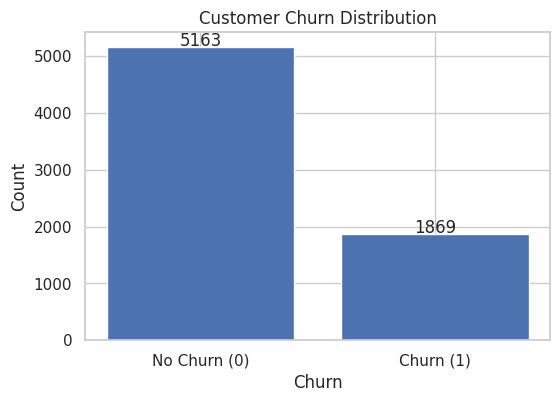

In [29]:
churn_counts = df["Churn"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["No Churn (0)", "Churn (1)"], churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 20, str(value), ha="center")
plt.show()

### [4.2] Contract Type and Churn

Contract type is a strong business variable because it reflects customer commitment. Month-to-month customers usually face fewer switching barriers than customers on annual contracts. If churn is visibly highest in the month-to-month group, this supports the idea that contract stability plays an important role in retention.

This insight has immediate strategic value. The company could target suitable month-to-month customers with offers that encourage them to move to longer-term contracts, especially where the model also predicts elevated churn risk.


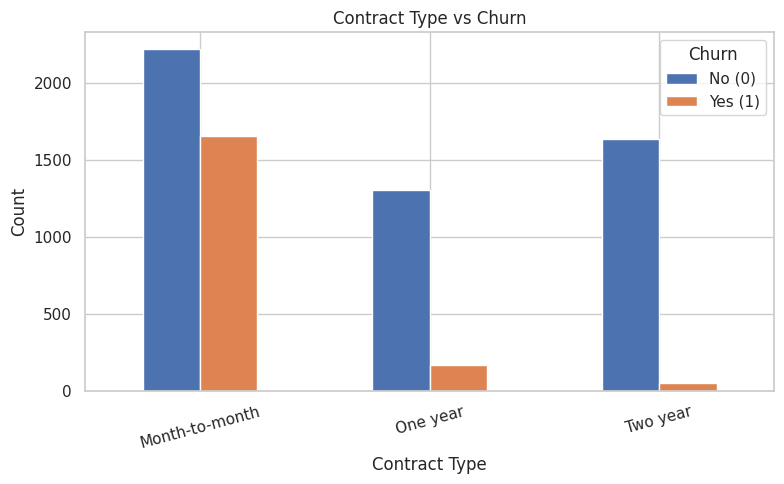

In [30]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])
contract_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.legend(title="Churn", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.show()

### [4.3] Monthly Charges and Churn

Monthly charges show the direct financial burden faced by the customer. If churn is associated with higher monthly charges, the business may have a value-perception problem. Customers may feel that the service they receive does not justify the price they are paying.

This variable is useful because it points toward pricing, bundling, and service-quality strategy. A high-charge customer who is also on a flexible contract may deserve more focused retention attention than a low-charge long-term customer.


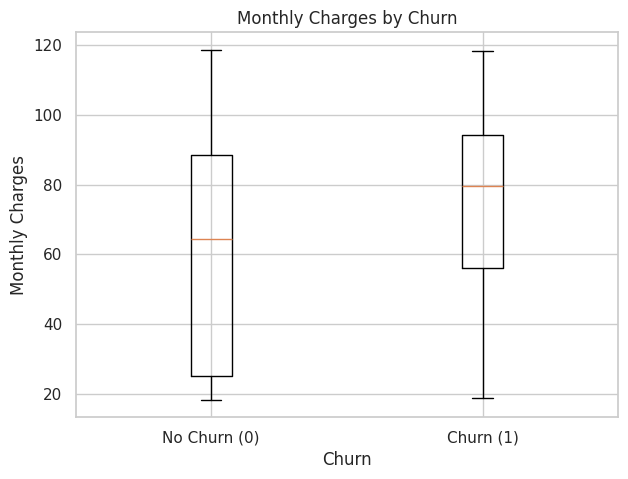

In [31]:
monthly_groups = [
    df.loc[df["Churn"] == 0, "MonthlyCharges"],
    df.loc[df["Churn"] == 1, "MonthlyCharges"]
]
plt.figure(figsize=(7, 5))
plt.boxplot(monthly_groups, labels=["No Churn (0)", "Churn (1)"])
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### [4.4] Tenure and Churn

Tenure is often one of the strongest retention variables because it measures how long the customer relationship has already lasted. If churn is concentrated among short-tenure customers, it suggests that the early stage of the customer lifecycle is especially risky.

This has strong managerial implications. Rather than treating retention as a late-stage rescue activity, the company may need better onboarding, first-bill communication, and early support to reduce churn during the first months of service.


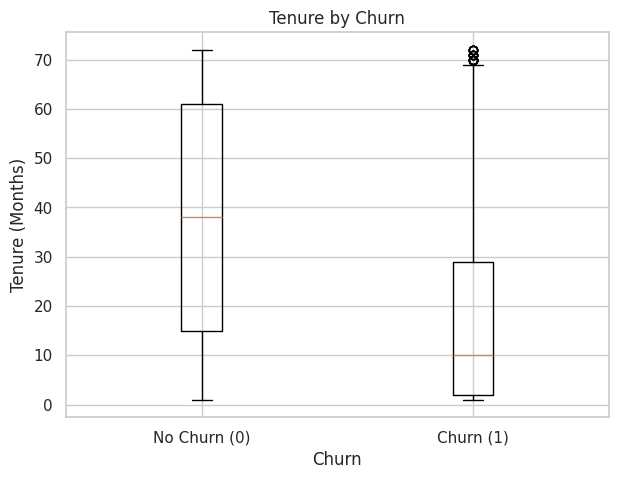

In [32]:
tenure_groups = [
    df.loc[df["Churn"] == 0, "tenure"],
    df.loc[df["Churn"] == 1, "tenure"]
]
plt.figure(figsize=(7, 5))
plt.boxplot(tenure_groups, labels=["No Churn (0)", "Churn (1)"])
plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### [4.5] Internet Service and Churn

Analysing churn by internet service type helps reveal whether some product groups are more vulnerable than others. If certain service categories show higher churn, the pattern may reflect different pricing levels, service expectations, or market competition.

This matters because churn management should not be one-dimensional. A retention strategy for fibre customers may differ from a strategy for DSL customers if their risk profile and service expectations are different.


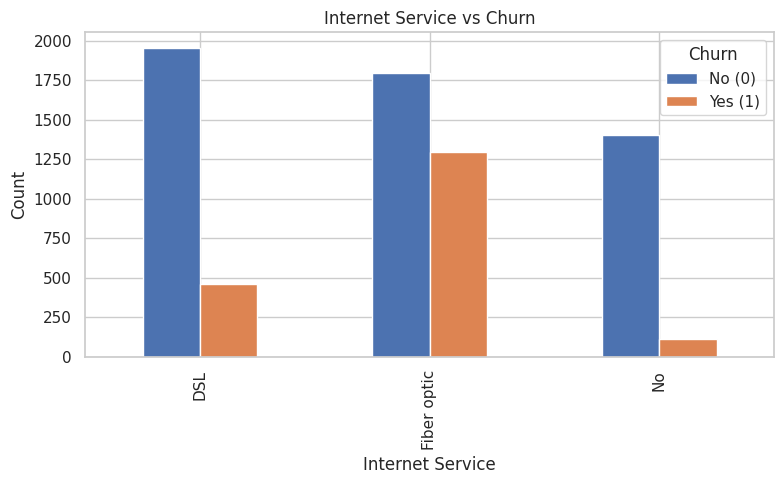

In [33]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])
internet_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.show()

### [4.6] Correlation Analysis

Correlation analysis is used to inspect how numeric variables move together. In this dataset, tenure, monthly charges, and total charges are particularly useful because they describe customer duration and financial intensity.

A correlation heatmap does not prove cause and effect, but it helps explain the structure of the dataset. It can also support interpretation later by showing whether important financial variables are closely related or whether they contribute distinct information to the churn story.


In [34]:
corr_target = pd.concat([X_encoded, y], axis=1).corr()["Churn"].sort_values(ascending=False)
corr_target.head(15)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
MonthlyCharges,0.192858
PaperlessBilling_Yes,0.191454
SeniorCitizen,0.150541
StreamingTV_Yes,0.063254
StreamingMovies_Yes,0.060860
MultipleLines_Yes,0.040033
PhoneService_Yes,0.011691


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
